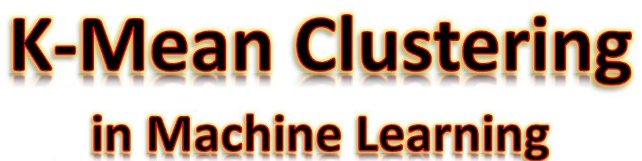


Neste projeto utilizarei a base [online shoppers purchase intention](https://archive.ics.uci.edu/ml/datasets/Online+Shoppers+Purchasing+Intention+Dataset) de Sakar, C.O., Polat, S.O., Katircioglu, M. et al. Neural Comput & Applic (2018). [Web Link](https://doi.org/10.1007/s00521-018-3523-0).

# Definição Técnica do Projeto

Este projeto tem como objetivo a **segmentação de clientes** com base em dados de navegação e comportamento de compra, utilizando técnicas de análise estatística e machine learning.  

A metodologia aplicada envolveu as seguintes etapas:

1. **Pré-processamento de dados**  
   - Limpeza e padronização da base de dados.  
   - Seleção de variáveis relevantes (ex.: PageValue, Bounce Rate, Revenue).  
   - Padronização dos dados numéricos para aplicação de algoritmos de clusterização.  

2. **Clusterização de clientes**  
   - Aplicação do algoritmo **K-Means** para identificar padrões de comportamento.  
   - Avaliação de métricas de qualidade dos clusters (Silhouette Score) para definição do número ótimo de grupos.  
   - Interpretação dos clusters em perfis acionáveis:  
     - **Compradores Ativos**  
     - **Pesquisam Antes de Comprar**  
     - **Não Engajados**  

3. **Análise de valor (PageValue)**  
   - Cálculo de estatísticas descritivas do PageValue por cluster.  
   - Estimativa de receita potencial atribuída a cada perfil de cliente.  
   - Identificação do grupo **“Pesquisam Antes de Comprar”** como segmento estratégico, com maior potencial de conversão em **Compradores Ativos**.  

4. **Recomendações de negócio**  
   - Definição de estímulos de marketing personalizados (remarketing, ofertas direcionadas, prova social).  
   - Priorização de investimentos em clientes com maior probabilidade de gerar receita.  
   - Estratégia de retenção focada em transformar clientes de alto potencial em compradores recorrentes.  

---

### Tecnologias Utilizadas
- **Python** (pandas, numpy, matplotlib, seaborn, scikit-learn)  
- **Jupyter Notebook** para análise e visualização  
- **Markdown** para documentação
- **Git/Git Hub** para versionamento  

---

### Objetivo Final

Responder a questão:

- **Por que os clientes que pesquisam antes de comprar são mais propensos à compra, apesar de serem estatisticamente inferiores aos clientes do grupo compras ativas?**

Demonstrarei, de forma analítica e visual, como a **ciência de dados aplicada à segmentação de clientes** pode gerar insights estratégicos para otimização de conversão, aumento de receita e eficiência em ações de marketing.

---

# Dataset
A base trata de registros de 12.330 sessões de acesso a páginas, cada sessão sendo de um único usuário em um período de 12 meses
|Variavel                |Descrição          | 
|------------------------|:-------------------| 
|Administrative          | Quantidade de acessos em páginas administrativas| 
|Administrative_Duration | Tempo de acesso em páginas administrativas | 
|Informational           | Quantidade de acessos em páginas informativas  | 
|Informational_Duration  | Tempo de acesso em páginas informativas  | 
|ProductRelated          | Quantidade de acessos em páginas de produtos | 
|ProductRelated_Duration | Tempo de acesso em páginas de produtos | 
|BounceRates             | *Percentual de visitantes que entram no site e saem sem acionar outros *requests* durante a sessão  | 
|ExitRates               | * Soma de vezes que a página é visualizada por último em uma sessão dividido pelo total de visualizações | 
|PageValues              | * Representa o valor médio de uma página da Web que um usuário visitou antes de concluir uma transação de comércio eletrônico | 
|SpecialDay              | Indica a proximidade a uma data festiva (dia das mães etc) | 
|Month                   | Mês  | 
|OperatingSystems        | Sistema operacional do visitante | 
|Browser                 | Browser do visitante | 
|Region                  | Região | 
|TrafficType             | Tipo de tráfego                  | 
|VisitorType             | Tipo de visitante: novo ou recorrente | 
|Weekend                 | Indica final de semana | 
|Revenue                 | Indica se houve compra ou não |

\* variávels calculadas pelo google analytics

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score
from tqdm.notebook import tqdm
from sklearn.metrics import silhouette_samples

In [3]:
# Carregando a base de dados

df = pd.read_csv('./online_shoppers_intention.csv')

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## Análise descritiva

- Analisar a distribuição das variáveis para compreender padrões e possíveis outliers.  
- Verificar a existência de valores ausentes (*missing values*) e definer a melhor estratégia de tratamento (remoção, imputação ou substituição).  
- Realizar tratamentos adicionais nas variáveis, caso necessário, assegurando a qualidade e consistência dos dados para as próximas etapas da análise.  

In [5]:
# Variáveis relevantes

variaveis = ['Administrative',
             'Administrative_Duration',
             'Informational',
             'Informational_Duration',
             'ProductRelated',
             'ProductRelated_Duration']

In [6]:
# Informações das colunas

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [7]:
# Verificando se há dados nulos ou faltantes

df.isna().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [8]:
# Verificando a distribuição das variáveis.

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


# Observações

### Qualidade dos dados
Escalas muito diferentes entre contagens e durações, isso implicará num tratamento com ```StandardScaler``` para padronizar os dados. Não há dados nulos.

## Features

### Adminstrative
Essas páginas podem estar relacionadas a informações de suporte, políticas, login ou questões administrativas. A **mediana = 1** demonstra um baixo acesso, porém existem sessões com até 27 páginas, o que posteriormente podemos investigar um possível ```outliers```.

### Administrative_Duration
Provavelmente o tempo está sendo medido em segundos, sendo a **mediana = 7,5s**, o que sugere que boa parte dos usuários passam rapidamente por esse tipo de página.
Registros com 3398s (```~56 minutos```) indicam usuários que podem ter ficado presos ou consultando detalhes administrativos mais longos.

### Informational
FAQ, conteúdo explicativo e instruções estão geralmente neste escopo de página. A **mediana = 0** demonstra que a maioria dos usuários não visitam essas páginas, todavia, há casos isolados de até 24 páginas informativas visitadas, o que merece uma investigação posterior.

### Informational_Duration
Tempo total gasto em segundos. A **mediana = 0** corrobora com a ideia de que poucos usuários visitam estas páginas. Porém, uma informação chama a atenção: valor máximo de ```2549s```(~42 minutos). Isso pode indicar que, dos poucos que visitam essas páginas, existem usuários que fazem uma busca detalhada antes de comprar ou que a página informativa foi esquecida em uma aba aberta.

### ProductRelated
É a variáveis mais expressiva, com **mediana = 18** páginas por sessão, com **mean = 32**. Há casos extremos de usuários que navegaram por mais de ```700 páginas```, indicando busca intensiva ou erro no dataset.

### ProductRelated_Duration
Também contabilizado em segundos, assim como as demais variáveis de duração. Para fins de envolvimento com o catálogo, é a mais relevante para intenção de compra. Sua **mediana = 599s** (~10 minutos) evidencia um tempo muito superior ao gasto nas demais páginas, com valores extremos em **18 horas** de acesso.

### BounceRates  
Essa métrica indica a **taxa de rejeição** das páginas, ou seja, a proporção de visitantes que entram e saem sem interagir.  
A mediana = 0 sugere que a maioria das sessões não apresenta rejeição imediata, mas valores chegando a 0,20 mostram que existem casos relevantes de abandono precoce. Isso pode indicar **páginas pouco atrativas** ou **problemas de usabilidade**.  

### ExitRates  
Representa a **taxa de saída**, ou seja, a frequência em que uma página foi a última da sessão.  
A mediana = 0,025 mostra que boa parte das páginas é ponto final da navegação. Valores próximos a 0,20 em algumas sessões podem indicar **abandonos no funil de compra**, especialmente se ocorrerem em páginas críticas (como checkout ou carrinho).  

### PageValues  
Reflete o **valor monetário médio atribuído às páginas**, considerando seu impacto em conversões.  
A mediana = 0 revela que a maioria das páginas não contribui diretamente para receita. No entanto, o valor máximo de 361 sugere que **determinadas páginas têm alto peso na geração de vendas** — normalmente associadas a produtos, carrinho e checkout.  


---

## Próximos passos
Aplicarei o ```StandardScaler``` e analisarei os resultados.

In [10]:
padronizar = StandardScaler()

# Selecionando apenas as variáveis numéricas
df_numerico = df.select_dtypes(include=['int64', 'float64'])

df_pad = padronizar.fit_transform(df_numerico)

## Como definir o número de clusters?  

Para encontrar a quantidade ideal de clusters, utilizei métricas de avaliação que ajudam a medir a qualidade da segmentação:  

1. **Método do Cotovelo (Elbow Method)**  
   - Calcula o *inertia* (soma das distâncias dos pontos ao centróide do cluster).
   - O ponto onde a redução começa a ser menos significativa (o "cotovelo" da curva) sugere o número ideal de clusters.  

2. **Coeficiente de Silhueta (Silhouette Score)**  
   - Mede o quão semelhantes os pontos estão dentro de um cluster em comparação com outros clusters.  
   - Varia de -1 a 1:  
     - Valores próximos de **1** → clusters bem separados.  
     - Valores próximos de **0** → sobreposição entre clusters.  
     - Valores negativos → pontos classificados no cluster errado.  
   - O número de clusters com maior *Silhouette Score* costuma ser o mais adequado.  

3. **Análise de Negócio**  
   - Mesmo que estatisticamente seja sugerido um número X de clusters, é fundamental verificar se eles fazem sentido no contexto do negócio.  
   - Por exemplo: 2 clusters podem simplificar demais a análise, enquanto 3 ou 4 podem revelar segmentos mais estratégicos e acionáveis.  

Neste projeto, combinei o **método estatístico (Silhouette)** com a **relevância prática para o negócio**, garantindo que os clusters encontrados sejam ao mesmo tempo **tecnicamente válidos e úteis para tomada de decisão**.

In [12]:
# Dicionário vazio para armazenar o score da silhueta
silhuetas = []

# Número máximo de clusters
max_clusters = 10
  
for n_clusters in tqdm(range(2, max_clusters+1)):
    km = KMeans(n_clusters=n_clusters).fit(df_pad)
    score = silhouette_score(df_pad, km.labels_)
    silhuetas.append(score)

  0%|          | 0/9 [00:00<?, ?it/s]

Melhor k = 2, coeficiente da silhueta = 0.3219


,n_clusters,silhueta_media
0,2,0.321906
1,3,0.235550
2,4,0.280634
3,5,0.162505
4,6,0.186593
5,7,0.169974
6,8,0.189269
7,9,0.191325
8,10,0.162612


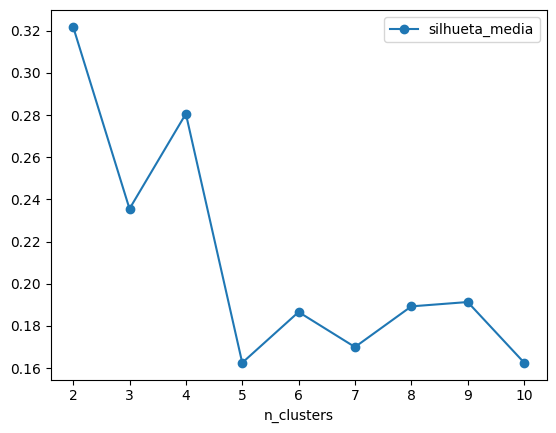

In [13]:
# Criando um dataframe para construir o gráfico
graf_silhueta = pd.DataFrame({'n_clusters': list(range(2, max_clusters+1)),
                             'silhueta_media': silhuetas})

# Construindo o gráfico
graf_silhueta.plot.line(x = 'n_clusters',
                       y = 'silhueta_media',
                       marker = 'o');

#------------------------------------------------------------------------------------------------#

melhor_idx = graf_silhueta['silhueta_media'].idxmax()        # índice do melhor score
melhor_k = graf_silhueta.loc[melhor_idx, 'n_clusters']       # valor do k
melhor_score = graf_silhueta.loc[melhor_idx, 'silhueta_media']  # valor do coeficiente

print(f'Melhor k = {int(melhor_k)}, coeficiente da silhueta = {melhor_score:.4f}')

graf_silhueta

## Otimização do K-Means  

Durante a análise, surgiu a questão: **como aumentar a silhueta média e melhorar a separação entre clusters?**  

Após pesquisa e experimentação, identifiquei dois caminhos principais:  

1. **Transformação logarítmica (`log1p`)**  
   - Aplicada em variáveis com distribuição altamente assimétrica.  
   - Reduz o impacto de valores extremos (*outliers*) e melhora a normalização dos dados.  

2. **Redução de dimensionalidade com PCA**  
   - Simplifica o espaço de variáveis mantendo a maior parte da variância explicada.  
   - Ajuda a eliminar redundâncias e ruídos, tornando os clusters mais distintos.  

Essas técnicas, combinadas, aumentaram a qualidade da segmentação e resultaram em clusters mais bem definidos e interpretáveis.  


In [15]:
# Novo DataFrame
new_df = pd.DataFrame(df_numerico)

# Aplicar log1p nas variáveis com distribuição altamente assimétricas
for col in ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']:
    new_df[col] = np.log1p(new_df[col])

new_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,2.306655,2.364922,0.0,0.000000,2.140066,4.546017,8.131457
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,0.844331,1.816394,0.0,0.000000,0.000000,0.000000,7.843996
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,5.962529,2.043091,0.0,5.221099,6.396824,7.289718,11.066240
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


In [16]:
# Definindo o método PCA
pca = PCA(n_components=3)

# Treinando e transformando o modelo com PCA
df_analise_pca = pca.fit_transform(new_df)

#------------------------------------------------------------------------------------------------#

# Novo dicionário para armazenar o score da silhueta com log
new_silhuetas = [] 
max_clusters = 10
  
for n_clusters in tqdm(range(2, max_clusters+1)):
    km = KMeans(n_clusters=n_clusters).fit(df_analise_pca)
    score = silhouette_score(df_analise_pca, km.labels_)
    new_silhuetas.append(score)

  0%|          | 0/9 [00:00<?, ?it/s]

Melhor k = 2, coeficiente da silhueta = 0.7349


,n_clusters_log,silhueta_media_log
0,2,0.734903
1,3,0.631468
2,4,0.639930
3,5,0.577421
4,6,0.509608
5,7,0.478732
6,8,0.514446
7,9,0.513938
8,10,0.481529


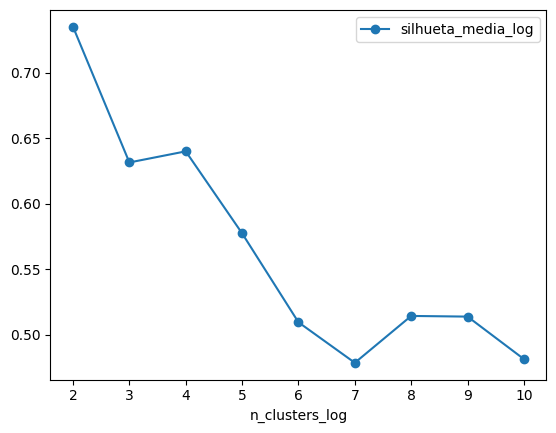

In [17]:
# Criando o DataFrame para construir o novo gráfico
new_graf_silhueta = pd.DataFrame({'n_clusters_log': list(range(2, max_clusters+1)),
                             'silhueta_media_log': new_silhuetas})

# Construindo o gráfico com as variáveis com log
new_graf_silhueta.plot.line(x = 'n_clusters_log',
                       y = 'silhueta_media_log',
                       marker = 'o');
#------------------------------------------------------------------------------------------------#

melhor_idx = new_graf_silhueta['silhueta_media_log'].idxmax()        # índice do melhor score
melhor_k = new_graf_silhueta.loc[melhor_idx, 'n_clusters_log']       # valor do k
melhor_score = new_graf_silhueta.loc[melhor_idx, 'silhueta_media_log']  # valor do coeficiente

print(f'Melhor k = {int(melhor_k)}, coeficiente da silhueta = {melhor_score:.4f}')
new_graf_silhueta

In [18]:
# Concatenando os dois DataFrames para fazer a comparação entre as silhuetas com e sem log
df_concat = pd.concat([graf_silhueta, 
                       new_graf_silhueta], 
                      axis=1, ignore_index=False)
df_concat

,n_clusters,silhueta_media,n_clusters_log,silhueta_media_log
0,2,0.321906,2,0.734903
1,3,0.235550,3,0.631468
2,4,0.280634,4,0.639930
3,5,0.162505,5,0.577421
4,6,0.186593,6,0.509608
5,7,0.169974,7,0.478732
6,8,0.189269,8,0.514446
7,9,0.191325,9,0.513938
8,10,0.162612,10,0.481529


## Tratamento dos clusters

Observa-se uma mudança significativa nos dados tratados com ```log``` e ```PCA``` para clusterização.

Os **`coeficientes de Silhueta`** sem log são baixos, indicando clusters pouco definidos. Os valores aumentaram exponencialmente com a aplicação do log e PCA, dobrando os valores da média.

A transformação *log* faz com que o K-Means consiga identificar melhor a estrutura dos dados, gerando clusters mais significativos. 

Por exemplo, no modelo *sem log* temos oscilações acentuadas nos *n_cluster = 4* até *7*, já o modelo *com log* temos um declive suave e progressivo até o *n_cluster = 8*, com uma quedra brusca no *9* e um retorno acentuado no *10*.

Mas por que isso acontece?

O coeficiente de silhueta não segue uma linha decrescente em relação ao número de clusters. O log muda a geometria dos dados e em alguns pontos a silhueta volta a subir porque o número de clusters se ajustou melhor à estratura desses dados. 

---

## Avaliação dos Grupos  

Para identificar a segmentação mais adequada, realizei uma análise descritiva comparando diferentes valores de **n_clusters**.  
Além dos indicadores estatísticos (como silhueta média e distribuição de variáveis), também considerei a **perspectiva de negócio**, avaliando o impacto potencial de cada grupo em termos de receita, engajamento e oportunidades de conversão.  

Esse processo uniu a visão analítica baseada em dados com o olhar estratégico, permitindo escolher a configuração de clusters que não apenas apresenta boa performance técnica, mas também gera **insights acionáveis** para a empresa.  

---

### 2 clusters
Possui a maior média, com *0,73*. Porém, vejo que a discriminação em 2 grupos é pouco informativo, pois separa o grupo em **compradores** e **não compradores**, por exemplo. Visto que o objetivo do negócio é tentar agrupar os clientes conforme seu comportamento de navegação entre páginas administrativas, informativas e de produtos, acredito que não seja o mais aconselhável escolher apenas dois grupos.

### 3 clusters
Embora a análise estatística inicial apontasse para apenas 2 agrupamentos, a opção por segmentar em 3 revelou um público-alvo extremamente valioso que, de outra forma, permaneceria invisível. Essa classificação em 3 clusters me possibilitou organizar os clientes em categorias distintas e operacionais, permitindo uma compreensão mais profunda do comportamento, maior precisão nas ações de marketing e vendas, além de oferecer subsídios concretos para decisões estratégicas. Por estas razões, escolhi trabalhar com 3 clusters.

- ```Compradores ativos```: visitam várias páginas de produtos e passam mais tempo navegando.

- ```Pesquisadores antes de comprar```: visitam páginas informacionais, navegam um pouco mais devagar. Compram, mas depois de pesquisar, comportamento intermediário.

- ```Não engajados```: navegação rápida, pouco interesse em produtos.

### 4 cluster
Apesar de a média apresentar resultados semelhantes quando utilizamos 3 clusters, a escolha por esse número é mais adequada para este caso de negócio. Isso porque:
- Três grupos já conseguem responder de forma consistente à questão central: identificar quais clientes são mais propensos à compra.
- Incluir um quarto cluster não agrega novos insights relevantes, apenas aumenta a complexidade da análise sem ganho prático.
- A simplicidade na segmentação facilita tanto a interpretação dos resultados quanto a aplicação de estratégias de marketing direcionadas.

---

## Avaliação de Resultados  

Nesta etapa, o foco foi responder à questão central do projeto:  

- **Qual grupo concentra os clientes mais propensos à compra?**  

Para isso, conduzi uma análise detalhada das variáveis, não apenas sob a ótica estatística, mas também considerando o **contexto de negócio**.  
Esse processo permitiu gerar **insights estratégicos** para apoiar decisões gerenciais e propor **ações de marketing direcionadas**, aumentando as chances de conversão e retenção de clientes.  


In [22]:
# Features escolhidas (sem Revenue)
features = ['Administrative', 'Administrative_Duration',
            'Informational', 'Informational_Duration',
            'ProductRelated', 'ProductRelated_Duration',
            'BounceRates', 'ExitRates', 'PageValues',
            'SpecialDay', 'OperatingSystems', 'Browser',
            'Region', 'TrafficType']
X = new_df[features]

# Acrescentando a Revenue ao DataFrame.
new_df['Revenue'] = df['Revenue']

#------------------------------------------------------------------------------------------------#

# Usando 3 grupos para estruturar o k-means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Criando uma coluna com o resultado do rótulo ao qual cada cliente pertence
new_df['cluster'] = kmeans.fit_predict(X)

new_df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Revenue,cluster
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,1,1,1,1,False,2
1,0,0.0,0,0.0,2,4.174387,0.00,0.10,0.0,0.0,2,2,1,2,False,2
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,4,1,9,3,False,2
3,0,0.0,0,0.0,2,1.299283,0.05,0.14,0.0,0.0,3,2,2,4,False,2
4,0,0.0,0,0.0,10,6.443336,0.02,0.05,0.0,0.0,3,3,1,4,False,2


## Análise com 3 grupos

Para esta nova etapa de análise, utilizei as seguintes *features* como base para compreender melhor o comportamento dos clientes.  
A partir delas, foi possível interpretar os rótulos atribuídos pelo modelo de clusterização e identificar **qual grupo melhor responde à questão central do projeto**.  


|Variavel                |Descrição          | 
|------------------------|:-------------------| 
|ProductRelated_Duration | Tempo de acesso em páginas de produtos | 
|BounceRates             | *Percentual de visitantes que entram no site e saem sem acionar outros *requests* durante a sessão  | 
|ExitRates               | * Soma de vezes que a página é visualizada por último em uma sessão dividido pelo total de visualizações | 
|PageValues              | * Representa o valor médio de uma página da Web que um usuário visitou antes de concluir uma transação de comércio eletrônico | 
|Revenue                 | Indica se houve compra ou não |

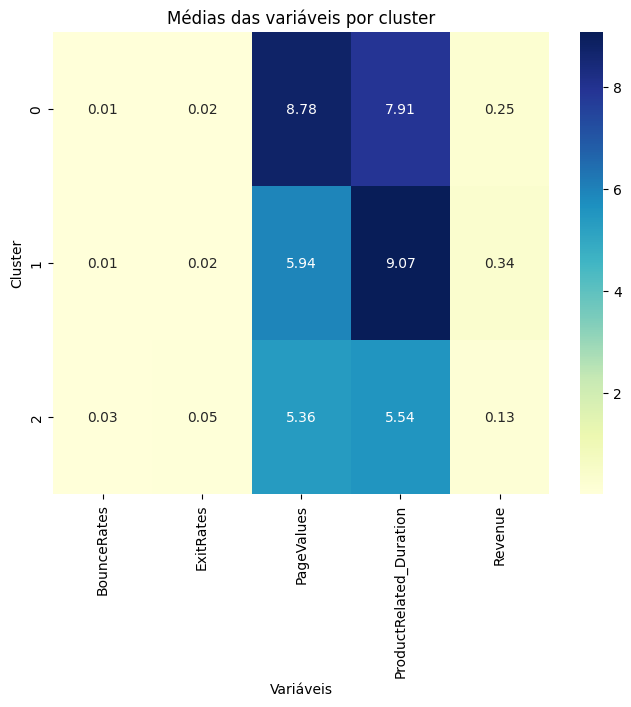

,BounceRates,ExitRates,PageValues,ProductRelated_Duration,Revenue
cluster,,,,,
0,0.006507,0.019520,8.777629,7.907596,0.251459
1,0.005236,0.017393,5.936001,9.073080,0.341709
2,0.025406,0.047905,5.356964,5.544273,0.133320


In [24]:
# médias das variáveis-chave em cada cluster
variaveis_chave = ['BounceRates', 'ExitRates', 'PageValues', 'ProductRelated_Duration', 'Revenue']
df_comparacao = new_df.groupby('cluster')[variaveis_chave].mean()

plt.figure(figsize=(8,6))
sns.heatmap(df_comparacao,
            annot=True,
            fmt='.2f',
            cmap='YlGnBu')
plt.title('Médias das variáveis por cluster')
plt.ylabel('Cluster')
plt.xlabel('Variáveis')
plt.show()

df_comparacao

# Análise de Clusters — Segmentação de Clientes

Nesta etapa, apresentarei a segmentação dos clientes com o objetivo de demonstrar como as métricas foram interpretadas, quais caminhos analíticos conduziram às informações obtidas, a definição dos perfis identificados e, por fim, recomendações práticas para retenção dos clientes mais relevantes e captação dos clientes menos engajados.

## Cluster 1 — “Compradores ativos”
- **Maior taxa de conversão (34%)** e maior **ProductRelated_Duration (9.07)**.  
- **Bounce/Exit muito baixos** → visitantes permanecem no site e não abandonam logo.  
- **PageValues moderado (5.94)** — não é o mais alto, mas o tempo em produto é o maior.  

**Interpretação:**  
Usuários que passam tempo em páginas de produto, examinam detalhes e convertem. Perfil valioso e com alto engajamento.  

**Ações recomendadas:**  
- Programas de retenção / upsell (cross-sell, bundles).  
- Incentivos de fidelização (cupom pós-compra, e-mails de recompra).  
- Priorizar A/B tests de checkout para aumentar AOV (valor médio do pedido).  

---

## Cluster 0 — “Pesquisadores antes de comprar”
- **Taxa de conversão alta-moderada (25%)**.  
- **PageValues mais alto (8.78)** — sessões com páginas que historicamente trazem valor.  
- **Tempo em produto mediano (7.91)**, bounce/exit baixos.  

**Interpretação:**  
Exploram bastante, visitam páginas que têm boa performance (por isso PageValues alto), mas convertem menos que cluster 1 — parecem comparar/avaliar antes de comprar.  

**Ações recomendadas:**  
- Conteúdo que ajude decisão: comparativos, avaliações, Q&A, frete gratuito no carrinho.  
- Remarketing com provas sociais e ofertas segmentadas (recuperação de carrinho, ofertas personalizadas).  
- Testar CTAs mais claros em páginas com grande PageValue.  

---

## Cluster 2 — “Não compradores” (ou baixo-engajamento)
- **Menor taxa de conversão (13%)**.  
- **Bounce/Exit bem maiores (2,54% e 4,79%)** — comparativamente ~4x os outros.  
- **PageValues e ProductRelated_Duration mais baixos** → menor engajamento e menos interação com páginas de valor.  

**Interpretação:**  
Tráfego de baixa qualidade ou visitantes pouco engajados — muitas sessões rápidas, poucos que chegam a considerar compra.  

**Ações recomendadas:**  
- Revisar origem do tráfego (canais/campanhas): ajustar segmentação, excluir fontes de baixo ROI.  
- Melhorar landing pages (mensagem, velocidade, experiência mobile).  
- Captura de e-mails/lead magnets para nutrir (em vez de tentar converter na primeira visita).  
- Retargeting com oferta de entrada (frete grátis, desconto inicial) para mover alguns para grupo pesquisador.  

---

In [26]:
# Renomeando a coluna cluster com os respectivos grupos

dic_clusters = {0:'Pesquisam_antes_compra',
                1:'Compradores_ativos',
                2:'Nao_engajados'}

new_df['cluster'] = new_df['cluster'].map(dic_clusters)
new_df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Revenue,cluster
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,1,1,1,1,False,Nao_engajados
1,0,0.0,0,0.0,2,4.174387,0.00,0.10,0.0,0.0,2,2,1,2,False,Nao_engajados
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,4,1,9,3,False,Nao_engajados
3,0,0.0,0,0.0,2,1.299283,0.05,0.14,0.0,0.0,3,2,2,4,False,Nao_engajados
4,0,0.0,0,0.0,10,6.443336,0.02,0.05,0.0,0.0,3,3,1,4,False,Nao_engajados


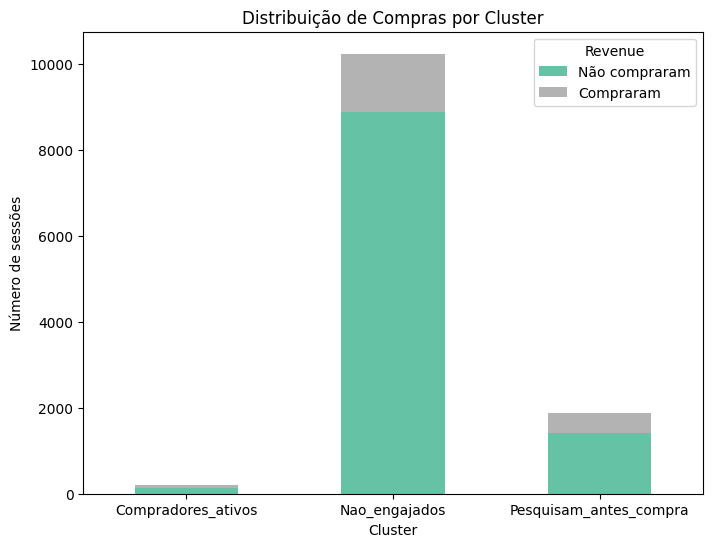

,Não compraram,Compraram
cluster,,
Compradores_ativos,131,68
Nao_engajados,8880,1366
Pesquisam_antes_compra,1411,474


In [27]:
# Cruzei as tabelas para apresentar o resumo dos insights do Revenue
crosstab = pd.crosstab(new_df['cluster'], new_df['Revenue'])

# Renomeando as colunas para ficar mais claro
crosstab.columns = ['Não compraram', 'Compraram']

# Plotando gráfico de barras empilhadas
crosstab.plot(kind='bar', stacked=True, figsize=(8,6), colormap="Set2")

plt.title("Distribuição de Compras por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Número de sessões")
plt.xticks(rotation=0)
plt.legend(title="Revenue")
plt.show()

crosstab

## Resumo

| Cluster | % Compradores (Revenue) | Características principais                          | Nome sugerido                  |
|---------|--------------------------|-----------------------------------------------------|--------------------------------|
| **0**   | 25%                     | PageValues alto, navegação média, baixa rejeição    | Pesquisadores antes de comprar |
| **1**   | 34%                     | Mais tempo em produtos, menor bounce, maior compra  | Compradores ativos             |
| **2**   | 13%                     | Bounce alto, pouco tempo, menor conversão           | Não engajados                |

Isso confirma que o **Cluster 1** (Compradores ativos) tem maior taxa de conversão, mas o **Cluster 0** (Pesquisam antes de comprar) é o mais estratégico por ter mais usuários próximos da compra.

In [29]:
new_df.groupby('cluster')['PageValues'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
Compradores_ativos,199.0,5.936001,17.616761,0.0,0.0,0.888486,5.553297,177.528825
Nao_engajados,10246.0,5.356964,17.546956,0.0,0.0,0.000000,0.000000,361.763742
Pesquisam_antes_compra,1885.0,8.777629,23.227015,0.0,0.0,0.000000,7.542144,360.953384


## Pesquisadores antes de comprar
- Têm **maior média de PageValue**.  
- Porém, como a **mediana é 0**, só alguns realmente visitam páginas de alto valor (ex.: checkout, produtos premium).  
- **Potencial estratégico**: podem se converter em compradores se estimulados no momento certo (*remarketing, ofertas personalizadas*).  

---

## Compradores ativos
- Apesar de não terem a maior média, possuem **mediana > 0**, indicando que muitos clientes **consistentemente geram valor**.  
- É o grupo mais **previsível e confiável para conversão**.  

---

## Não engajados
- A maioria não gera PageValue (**mediana = 0**).  
- O pouco valor observado vem de **outliers**, não de comportamento recorrente.  
- **Menor prioridade em estratégias de retenção**.  

---

# Insights Financeiros por Cluster

## Receita Estimada por Cluster

| Cluster                     | Receita Estimada (PageValue) |
|-----------------------------|------------------------------|
| Compradores ativos          | R\$ 1.181                    |
| Pesquisam antes de comprar  | R\$ 16.546                   |
| Não engajados               | R\$ 54.887                   |

## Interpretação
- **Compradores ativos** → receita menor em volume, mas mais **constante e previsível**.  
- **Pesquisam antes de comprar** → receita potencial relevante, mas dependente de estímulos para efetivar a compra.  
- **Não engajados** → concentram o maior volume, mas de forma **muito irregular** (pouca conversão real).

 
O modelo mostra que, embora o grupo de “Não engajados” concentre o maior PageValue bruto, o **maior retorno estratégico** está em estimular os *Pesquisadores antes de comprar*.  
Ações como **remarketing, descontos direcionados e personalização da jornada** podem converter parte desse potencial em receita real.


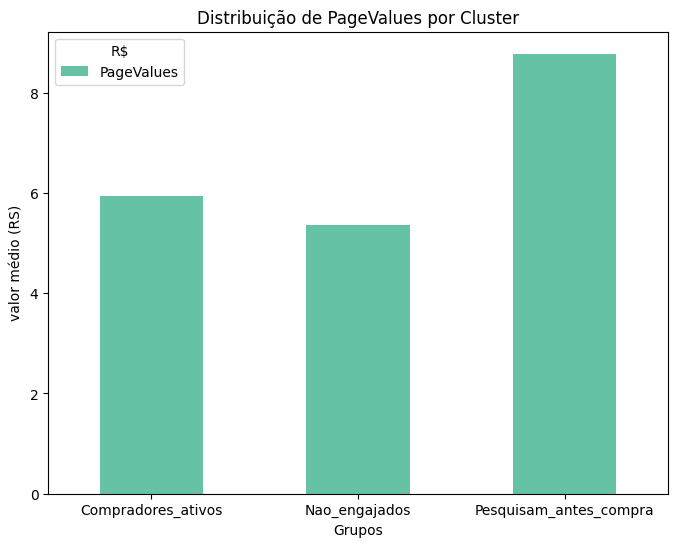

,PageValues
cluster,
Compradores_ativos,5.936001
Nao_engajados,5.356964
Pesquisam_antes_compra,8.777629


In [32]:
df_grouped = pd.DataFrame(new_df.groupby("cluster")["PageValues"].mean())

df_grouped.plot(kind='bar', stacked=True, figsize=(8,6), colormap="Set2")

plt.title("Distribuição de PageValues por Cluster")
plt.xlabel("Grupos")
plt.ylabel("valor médio (RS)")
plt.xticks(rotation=0)
plt.legend(title="R$")
plt.show()

df_grouped

## Qual grupo possui clientes mais propensos à compra?

| Cluster                    | Taxa de Conversão | PageValue Médio | Receita Estimada (PageValue) | Interpretação Executiva |
|-----------------------------|------------------:|----------------:|-----------------------------:|--------------------------|
| Compradores ativos         | Alta (≈34%)       | R\$ 5,94         | R\$ 1.181                    | Grupo confiável, já gera valor de forma consistente |
| **Pesquisam antes de comprar** | **Média (≈25%)**      | **R\$ 8,78**     | **R\$ 16.546**               | **Potencial estratégico: clientes que só precisam de estímulo certo para converter** |
| Não engajados              | Baixa (≈13%)      | R\$ 5,35         | R\$ 54.887                   | Alto volume, mas pouco retorno consistente  |


# Por que focar em "Pesquisam antes de comprar"

## 1. Alto potencial de receita
- Esse grupo apresenta o maior PageValue médio (R$ 8,78).  
- Quando interagem com páginas relevantes (ex.: carrinho, checkout), geram mais valor por visita do que qualquer outro cluster.  

## 2. Comportamento estratégico
- Embora nem todos convertam, o fato de pesquisarem antes de decidir indica que estão em um estágio avançado da jornada de compra.  
- São clientes quase prontos para comprar, apenas aguardando um incentivo (remarketing, oferta direcionada, frete grátis).  

## 3. Margem de crescimento
- A taxa de conversão ainda não é a mais alta, mas existe espaço para ganho.  
- Com estratégias adequadas, parte desse grupo pode migrar para o perfil de "Compradores Ativos".  

## 4. Eficiência de investimento
- Diferente dos "Não Engajados", onde o esforço dificilmente se paga, esse cluster concentra clientes que respondem melhor a estímulos de marketing.  
- Isso torna os investimentos mais eficazes e com maior retorno.  

---

### Conclusão
Focar no cluster ```"Pesquisam antes de comprar"``` significa apostar em clientes estratégicos, com alto valor potencial e grande margem de conversão adicional.  
Esse grupo representa o elo de crescimento sustentável entre manter os compradores fiéis e descartar esforços improdutivos com clientes não engajados.
Eles já demonstraram interesse real. O papel do marketing é remover fricções e dar o empurrão final — seja com incentivos financeiros (desconto, frete grátis), seja com prova social e segurança.
Isso aumenta a chance de eles migrarem para o cluster Compradores Ativos, que é o mais consistente e rentável.

# Estímulos de Marketing para "Pesquisam antes de comprar"

| Objetivo              | Estímulo de Marketing                                                                 |
|-----------------------|----------------------------------------------------------------------------------------|
| **Converter**         | - Remarketing em Google/Meta Ads com produtos pesquisados                              |
|                       | - E-mails de abandono de carrinho com incentivo (ex.: desconto válido por 24h)         |
|                       | - Ofertas direcionadas (cupons exclusivos, descontos progressivos, combos promocionais)|
| **Fidelizar**         | - Programas de pontos ou cashback                                                      |
|                       | - Recomendações inteligentes com base em compras anteriores                            |
|                       | - Conteúdo de relacionamento (ex.: guias, dicas, tutoriais)                            |
| **Reduzir objeções**  | - Frete grátis ou upgrade de envio rápido                                              |
|                       | - Garantias claras (devolução grátis, suporte ativo, parcelamento facilitado)          |
|                       | - Prova social: avaliações, depoimentos e “últimas unidades” para gerar urgência       |
